In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/kavyanayyar/predictive-maintenance-dataset/ai4i2020.csv
/kaggle/input/notebooks/zacharyraup/predictive-maintenance-in-manufacturing/__results__.html
/kaggle/input/notebooks/zacharyraup/predictive-maintenance-in-manufacturing/__notebook__.ipynb
/kaggle/input/notebooks/zacharyraup/predictive-maintenance-in-manufacturing/__output__.json
/kaggle/input/notebooks/zacharyraup/predictive-maintenance-in-manufacturing/custom.css
/kaggle/input/notebooks/zacharyraup/predictive-maintenance-in-manufacturing/__results___files/__results___54_1.png
/kaggle/input/notebooks/zacharyraup/predictive-maintenance-in-manufacturing/__results___files/__results___19_0.png
/kaggle/input/notebooks/zacharyraup/predictive-maintenance-in-manufacturing/__results___files/__results___31_0.png
/kaggle/input/notebooks/zacharyraup/predictive-maintenance-in-manufacturing/__results___files/__results___45_0.png
/kaggle/input/notebooks/zacharyraup/predictive-maintenance-in-manufacturing/__results___files/

In [2]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/kavyanayyar/predictive-maintenance-dataset/ai4i2020.csv")

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
df.shape

(10000, 14)

In [4]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [6]:
df["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [7]:
df["Machine failure"].value_counts(normalize=True) * 100

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64



The dataset is imbalanced because machine failure cases occur much less frequently than normal operating conditions.

Therefore, model performance should be evaluated using precision, recall, and F1-score in addition to accuracy.

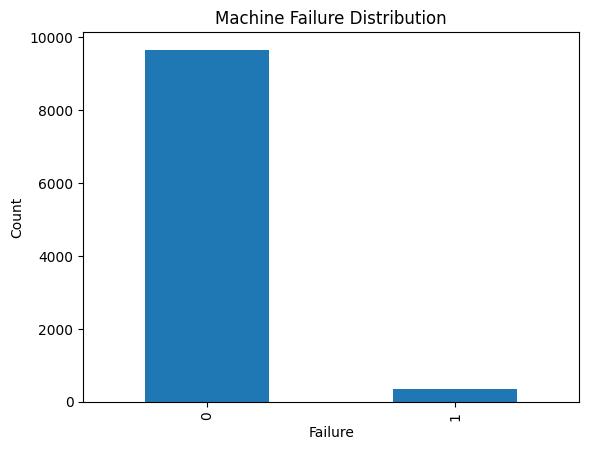

In [8]:
import matplotlib.pyplot as plt

df["Machine failure"].value_counts().plot(kind="bar")

plt.title("Machine Failure Distribution")
plt.xlabel("Failure")
plt.ylabel("Count")

plt.show()

In [9]:
columns_to_drop = [
    "UDI",
    "Product ID",
    "Machine failure",
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF"
]

X = df.drop(columns=columns_to_drop)

y = df["Machine failure"]

print(X.head())

  Type  Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0    M                298.1                    308.6                    1551   
1    L                298.2                    308.7                    1408   
2    L                298.1                    308.5                    1498   
3    L                298.2                    308.6                    1433   
4    L                298.2                    308.7                    1408   

   Torque [Nm]  Tool wear [min]  
0         42.8                0  
1         46.3                3  
2         49.4                5  
3         39.5                7  
4         40.0                9  


In [10]:
X = pd.get_dummies(X, columns=["Type"], drop_first=True)

X.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type_L,Type_M
0,298.1,308.6,1551,42.8,0,False,True
1,298.2,308.7,1408,46.3,3,True,False
2,298.1,308.5,1498,49.4,5,True,False
3,298.2,308.6,1433,39.5,7,True,False
4,298.2,308.7,1408,40.0,9,True,False


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(8000, 7)
(2000, 7)


In [18]:
from sklearn.model_selection import train_test_split


In [19]:
print(X.columns)

Index(['Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Type_L',
       'Type_M'],
      dtype='object')


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (8000, 7)
Testing set: (2000, 7)


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report

log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000))
])

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

[[1593  339]
 [  12   56]]
              precision    recall  f1-score   support

           0       0.99      0.82      0.90      1932
           1       0.14      0.82      0.24        68

    accuracy                           0.82      2000
   macro avg       0.57      0.82      0.57      2000
weighted avg       0.96      0.82      0.88      2000



In [22]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    max_depth=6
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [23]:
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

[[1854   78]
 [  12   56]]
              precision    recall  f1-score   support

           0       0.99      0.96      0.98      1932
           1       0.42      0.82      0.55        68

    accuracy                           0.95      2000
   macro avg       0.71      0.89      0.77      2000
weighted avg       0.97      0.95      0.96      2000



In [24]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
2,Rotational speed [rpm],0.339195
3,Torque [Nm],0.319694
4,Tool wear [min],0.197491
0,Air temperature [K],0.083673
1,Process temperature [K],0.046051
5,Type_L,0.008671
6,Type_M,0.005225


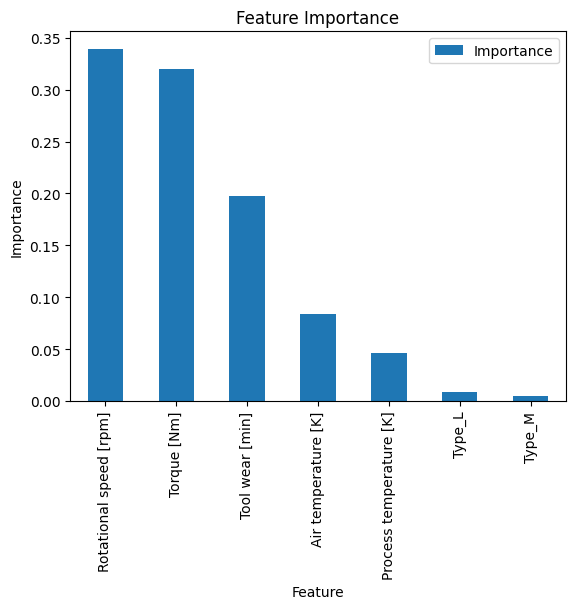

In [25]:
import matplotlib.pyplot as plt

feature_importance.plot(
    x="Feature",
    y="Importance",
    kind="bar"
)

plt.title("Feature Importance")
plt.ylabel("Importance")
plt.show()



Random Forest allows us to identify which sensor measurements contribute most to machine failure prediction.

Understanding feature importance is valuable because it helps engineers focus on the parameters that have the strongest relationship with equipment health and failure risk.

This project developed a machine learning-based predictive maintenance system using industrial sensor data.

The objective was to predict machine failures using operational parameters such as air temperature, process temperature, rotational speed, torque, tool wear, and machine type.

The dataset exhibited significant class imbalance, with failure cases accounting for only 3.39% of observations. Therefore, model performance was evaluated using precision, recall, and F1-score in addition to accuracy.

Two classification models were trained and compared:

- Logistic Regression
- Random Forest

Random Forest achieved superior performance, obtaining 95% accuracy while maintaining an 82% recall for machine failures. This indicates that the model successfully identified most failure cases while reducing false alarms.

This project demonstrates the application of machine learning techniques including data preprocessing, categorical encoding, train-test splitting, classification, model evaluation, and feature importance analysis to a real-world engineering problem.